# Live parked ADC counts vs single-batch and ODMR ADC

This notebook compares the latest live parked lock-in ADC counts against:

- the single-batch measurement in `multipoint_lockin_collected.csv`, and
- interpolated ODMR sweep ADC counts at the same parked frequencies.

By default it auto-selects the latest raw `multipoint_lockin_live_YYYYMMDD_HHMMSS.csv`, the latest `odmr_sweep_*.csv`, and the parked-plan CSV matching that ODMR sweep. You can still override any path in the setup cell.

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


def render(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


def find_workspace_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "nv_magnetometer_project").is_dir():
            return candidate
    raise FileNotFoundError("Could not find workspace root containing nv_magnetometer_project")


def latest_by_regex(directory: Path, pattern: str, regex: str) -> Path:
    compiled = re.compile(regex)
    matches = [path for path in directory.glob(pattern) if compiled.fullmatch(path.name)]
    if not matches:
        raise FileNotFoundError(f"No files in {directory} match {regex}")
    return sorted(matches, key=lambda path: path.name)[-1]


WORKSPACE_ROOT = find_workspace_root()
PROJECT_ROOT = WORKSPACE_ROOT / "nv_magnetometer_project"
DATA_ROOT = PROJECT_ROOT / "data"
LOCKIN_DIR = DATA_ROOT / "lockin_multipoint"
ODMR_DIR = DATA_ROOT / "odmr_sweeps"
OUT_DIR = LOCKIN_DIR / "adc_count_comparisons"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional manual overrides. Leave as None to use latest files automatically.
LIVE_CSV_OVERRIDE = None # old one is multipoint_lockin_live_20260508_151729.csv    
BATCH_CSV_OVERRIDE = None # old one is multipoint_lockin_collected_20260508_151729.csv
ODMR_CSV_OVERRIDE = None # old one is odmr_sweep_20260508_151729.csv    
PLAN_CSV_OVERRIDE = None # old one is parked_plan_odmr_sweep_20260508_151729.csv

LIVE_CSV = Path(LIVE_CSV_OVERRIDE) if LIVE_CSV_OVERRIDE else latest_by_regex(
    LOCKIN_DIR,
    "multipoint_lockin_live_*.csv",
    r"multipoint_lockin_live_\d{8}_\d{6}\.csv",
)
BATCH_CSV = Path(BATCH_CSV_OVERRIDE) if BATCH_CSV_OVERRIDE else LOCKIN_DIR / "multipoint_lockin_collected.csv"
ODMR_CSV = Path(ODMR_CSV_OVERRIDE) if ODMR_CSV_OVERRIDE else latest_by_regex(
    ODMR_DIR,
    "odmr_sweep_*.csv",
    r"odmr_sweep_\d{8}_\d{6}\.csv",
)
PLAN_CSV = Path(PLAN_CSV_OVERRIDE) if PLAN_CSV_OVERRIDE else LOCKIN_DIR / f"parked_plan_{ODMR_CSV.stem}.csv"

for path in [LIVE_CSV, BATCH_CSV, ODMR_CSV, PLAN_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

RUN_LABEL = LIVE_CSV.stem.replace("multipoint_lockin_live_", "")

print(f"Live CSV:  {LIVE_CSV}")
print(f"Batch CSV: {BATCH_CSV}")
print(f"ODMR CSV:  {ODMR_CSV}")
print(f"Plan CSV:  {PLAN_CSV}")
print(f"Outputs:   {OUT_DIR}")

Live CSV:  /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260508_151729.csv
Batch CSV: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv
ODMR CSV:  /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260508_151705.csv
Plan CSV:  /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260508_151705.csv
Outputs:   /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons


In [2]:
live_df = pd.read_csv(LIVE_CSV)
batch_df = pd.read_csv(BATCH_CSV)
odmr_df = pd.read_csv(ODMR_CSV)
plan_df = pd.read_csv(PLAN_CSV)

peak_nums = []
for col in live_df.columns:
    match = re.fullmatch(r"peak_(\d{2})", col)
    if match and f"{col}_ref" in live_df.columns and f"{col}_freq_mhz" in live_df.columns:
        peak_nums.append(int(match.group(1)))
peak_nums = sorted(peak_nums)

if len(batch_df) != 1:
    print(f"Batch CSV has {len(batch_df)} rows; this notebook uses row 0 as the single-batch comparison.")

print(f"Live rows: {len(live_df)}")
print(f"Batch rows: {len(batch_df)}")
print(f"ODMR points: {len(odmr_df)}")
print(f"Detected peak channels: {peak_nums}")

Live rows: 310
Batch rows: 1
ODMR points: 501
Detected peak channels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## Frequency-plan check

The live and batch files contain the actual parked frequencies in `peak_NN_freq_mhz`. The parked-plan file contains the frequencies expected from the current plan. This table makes any mismatch visible before comparing ADC values.

In [3]:
freq_rows = []
plan_freqs = plan_df["frequency_mhz"].to_numpy(dtype=float) if "frequency_mhz" in plan_df.columns else np.asarray([], dtype=float)

for i, n in enumerate(peak_nums):
    peak = f"peak_{n:02d}"
    freq_col = f"{peak}_freq_mhz"
    live_freq = float(np.nanmedian(live_df[freq_col].to_numpy(dtype=float)))
    batch_freq = float(batch_df.loc[0, freq_col]) if freq_col in batch_df.columns else np.nan
    plan_freq = float(plan_freqs[i]) if i < len(plan_freqs) else np.nan
    freq_rows.append({
        "peak": peak,
        "live_freq_mhz": live_freq,
        "batch_freq_mhz": batch_freq,
        "plan_freq_mhz": plan_freq,
        "live_minus_batch_mhz": live_freq - batch_freq,
        "live_minus_plan_mhz": live_freq - plan_freq,
    })

freq_check = pd.DataFrame(freq_rows)
freq_check_csv = OUT_DIR / f"frequency_plan_check_{RUN_LABEL}.csv"
freq_check.to_csv(freq_check_csv, index=False)
print(f"Saved: {freq_check_csv}")
display(freq_check.round(6))

if np.nanmax(np.abs(freq_check["live_minus_plan_mhz"].to_numpy(dtype=float))) > 1e-3:
    print("WARNING: live/batch parked frequencies do not match the current parked-plan CSV.")
    print("This usually means the live CSV was acquired with an older or different parked plan.")

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/frequency_plan_check_20260508_151729.csv


,peak,live_freq_mhz,batch_freq_mhz,plan_freq_mhz,live_minus_batch_mhz,live_minus_plan_mhz
0,peak_01,2628.999989,2628.999989,2761.711304,0.0,-132.711314
1,peak_02,2631.999988,2631.999988,2772.687970,0.0,-140.687982
2,peak_03,2762.999938,2762.999938,2797.450206,0.0,-34.450268
3,peak_04,2769.999936,2769.999936,2811.350713,0.0,-41.350778
4,peak_05,2800.999924,2800.999924,2835.616973,0.0,-34.617049
5,peak_06,2806.999921,2806.999921,2847.323552,0.0,-40.323631
6,peak_07,2837.999910,2837.999910,2869.873307,0.0,-31.873398
7,peak_08,2842.999908,2842.999908,2875.283196,0.0,-32.283288
8,peak_09,2877.999894,2877.999894,2878.246456,0.0,-0.246561
9,peak_10,2881.999893,2881.999893,2882.660225,0.0,-0.660332


This usually means the live CSV was acquired with an older or different parked plan.


## ADC comparison table

For each parked point, this compares:

- live mean and standard deviation across all live batches,
- single-batch ADC from `multipoint_lockin_collected.csv`,
- interpolated ODMR MW-on ADC at the parked frequency,
- the same comparison for the off-resonance/reference counts when available.

In [4]:
odmr_freq = odmr_df["frequency_MHz"].to_numpy(dtype=float)
odmr_on = odmr_df["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)
odmr_off = odmr_df["photoluminescence_mw_off_ADC"].to_numpy(dtype=float)

rows = []
for n in peak_nums:
    peak = f"peak_{n:02d}"
    ref = f"{peak}_ref"
    freq_col = f"{peak}_freq_mhz"
    freq = float(np.nanmedian(live_df[freq_col].to_numpy(dtype=float)))
    nearest_idx = int(np.nanargmin(np.abs(odmr_freq - freq)))
    odmr_on_interp = float(np.interp(freq, odmr_freq, odmr_on))
    odmr_off_interp = float(np.interp(freq, odmr_freq, odmr_off))

    live_signal = live_df[peak].to_numpy(dtype=float)
    live_ref = live_df[ref].to_numpy(dtype=float)
    batch_signal = float(batch_df.loc[0, peak])
    batch_ref = float(batch_df.loc[0, ref])

    rows.append({
        "peak": peak,
        "freq_mhz": freq,
        "odmr_nearest_freq_mhz": float(odmr_freq[nearest_idx]),
        "odmr_freq_error_mhz": freq - float(odmr_freq[nearest_idx]),
        "live_signal_mean_adc": float(np.nanmean(live_signal)),
        "live_signal_std_adc": float(np.nanstd(live_signal, ddof=1)),
        "live_signal_sem_adc": float(np.nanstd(live_signal, ddof=1) / np.sqrt(np.count_nonzero(np.isfinite(live_signal)))),
        "batch_signal_adc": batch_signal,
        "odmr_signal_interp_adc": odmr_on_interp,
        "live_minus_batch_adc": float(np.nanmean(live_signal) - batch_signal),
        "live_minus_odmr_adc": float(np.nanmean(live_signal) - odmr_on_interp),
        "batch_minus_odmr_adc": batch_signal - odmr_on_interp,
        "live_ref_mean_adc": float(np.nanmean(live_ref)),
        "live_ref_std_adc": float(np.nanstd(live_ref, ddof=1)),
        "batch_ref_adc": batch_ref,
        "odmr_ref_interp_adc": odmr_off_interp,
        "live_ref_minus_batch_ref_adc": float(np.nanmean(live_ref) - batch_ref),
        "live_ref_minus_odmr_ref_adc": float(np.nanmean(live_ref) - odmr_off_interp),
        "live_signal_over_ref_mean": float(np.nanmean(live_signal / live_ref)),
        "batch_signal_over_ref": batch_signal / batch_ref,
        "odmr_signal_over_ref_interp": odmr_on_interp / odmr_off_interp,
    })

comparison = pd.DataFrame(rows)
comparison_csv = OUT_DIR / f"live_vs_batch_vs_odmr_adc_{RUN_LABEL}.csv"
comparison.to_csv(comparison_csv, index=False)
print(f"Saved: {comparison_csv}")
display(comparison.round({
    "freq_mhz": 3,
    "odmr_nearest_freq_mhz": 3,
    "odmr_freq_error_mhz": 4,
    "live_signal_mean_adc": 3,
    "live_signal_std_adc": 3,
    "live_signal_sem_adc": 3,
    "batch_signal_adc": 3,
    "odmr_signal_interp_adc": 3,
    "live_minus_batch_adc": 3,
    "live_minus_odmr_adc": 3,
    "batch_minus_odmr_adc": 3,
    "live_ref_mean_adc": 3,
    "live_ref_std_adc": 3,
    "batch_ref_adc": 3,
    "odmr_ref_interp_adc": 3,
    "live_ref_minus_batch_ref_adc": 3,
    "live_ref_minus_odmr_ref_adc": 3,
    "live_signal_over_ref_mean": 6,
    "batch_signal_over_ref": 6,
    "odmr_signal_over_ref_interp": 6,
}))

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/live_vs_batch_vs_odmr_adc_20260508_151729.csv


,peak,freq_mhz,odmr_nearest_freq_mhz,odmr_freq_error_mhz,live_signal_mean_adc,live_signal_std_adc,live_signal_sem_adc,batch_signal_adc,odmr_signal_interp_adc,live_minus_batch_adc,...,batch_minus_odmr_adc,live_ref_mean_adc,live_ref_std_adc,batch_ref_adc,odmr_ref_interp_adc,live_ref_minus_batch_ref_adc,live_ref_minus_odmr_ref_adc,live_signal_over_ref_mean,batch_signal_over_ref,odmr_signal_over_ref_interp
0,peak_01,2629.0,2629.0,0.0,6615.250,21.362,1.213,6626.441,6644.757,-11.191,...,-18.315,6621.856,22.943,6633.048,6642.371,-11.192,-20.515,0.999003,0.999004,1.000359
1,peak_02,2632.0,2632.0,0.0,6627.786,24.968,1.418,6639.306,6646.209,-11.520,...,-6.903,6631.870,25.786,6642.915,6646.116,-11.045,-14.246,0.999385,0.999457,1.000014
2,peak_03,2763.0,2763.0,0.0,6605.014,18.604,1.057,6613.179,6610.852,-8.165,...,2.327,6611.712,19.625,6620.822,6616.860,-9.110,-5.149,0.998988,0.998846,0.999092
3,peak_04,2770.0,2770.0,0.0,6590.496,15.695,0.891,6595.145,6592.819,-4.649,...,2.326,6603.378,17.440,6610.608,6607.067,-7.229,-3.689,0.998050,0.997661,0.997843
4,peak_05,2801.0,2801.0,0.0,6600.635,16.914,0.961,6606.759,6618.177,-6.123,...,-11.418,6608.414,18.556,6617.820,6620.315,-9.406,-11.901,0.998824,0.998329,0.999677
5,peak_06,2807.0,2807.0,0.0,6604.509,17.565,0.998,6612.078,6615.252,-7.568,...,-3.175,6611.265,19.144,6620.296,6621.224,-9.031,-9.959,0.998979,0.998759,0.999098
6,peak_07,2838.0,2838.0,0.0,6607.204,19.734,1.121,6616.738,6630.115,-9.534,...,-13.377,6612.175,20.801,6622.305,6627.910,-10.130,-15.736,0.999249,0.999159,1.000333
7,peak_08,2843.0,2843.0,0.0,6609.419,20.554,1.167,6618.528,6623.935,-9.109,...,-5.407,6613.891,21.286,6623.801,6624.164,-9.910,-10.273,0.999324,0.999204,0.999965
8,peak_09,2878.0,2878.0,0.0,6580.954,21.615,1.228,6587.962,6599.307,-7.008,...,-11.344,6591.555,21.489,6599.391,6607.222,-7.837,-15.667,0.998392,0.998268,0.998802
9,peak_10,2882.0,2882.0,0.0,6566.948,16.548,0.940,6570.088,6572.701,-3.139,...,-2.613,6583.401,16.658,6588.555,6590.890,-5.154,-7.489,0.997502,0.997197,0.997240


## Signal ADC comparison plot

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/signal_adc_live_batch_odmr_20260508_151729.png


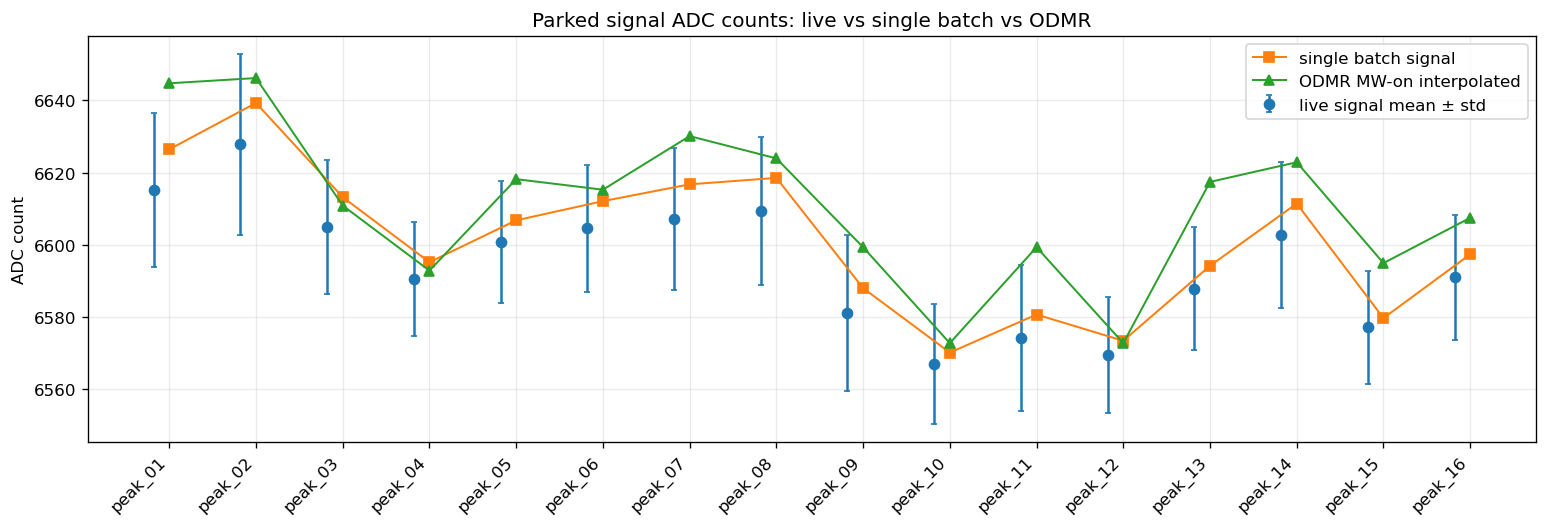

In [5]:
x = np.arange(len(comparison))
labels = comparison["peak"].tolist()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.errorbar(
    x - 0.18,
    comparison["live_signal_mean_adc"],
    yerr=comparison["live_signal_std_adc"],
    marker="o",
    linestyle="",
    capsize=2,
    label="live signal mean ± std",
)
ax.plot(x, comparison["batch_signal_adc"], marker="s", lw=1.2, label="single batch signal")
ax.plot(x, comparison["odmr_signal_interp_adc"], marker="^", lw=1.2, label="ODMR MW-on interpolated")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("ADC count")
ax.set_title("Parked signal ADC counts: live vs single batch vs ODMR")
ax.legend()
fig.tight_layout()
plot_path = OUT_DIR / f"signal_adc_live_batch_odmr_{RUN_LABEL}.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
print(f"Saved: {plot_path}")
render(fig)

## Difference from ODMR and single batch

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/signal_adc_differences_20260508_151729.png


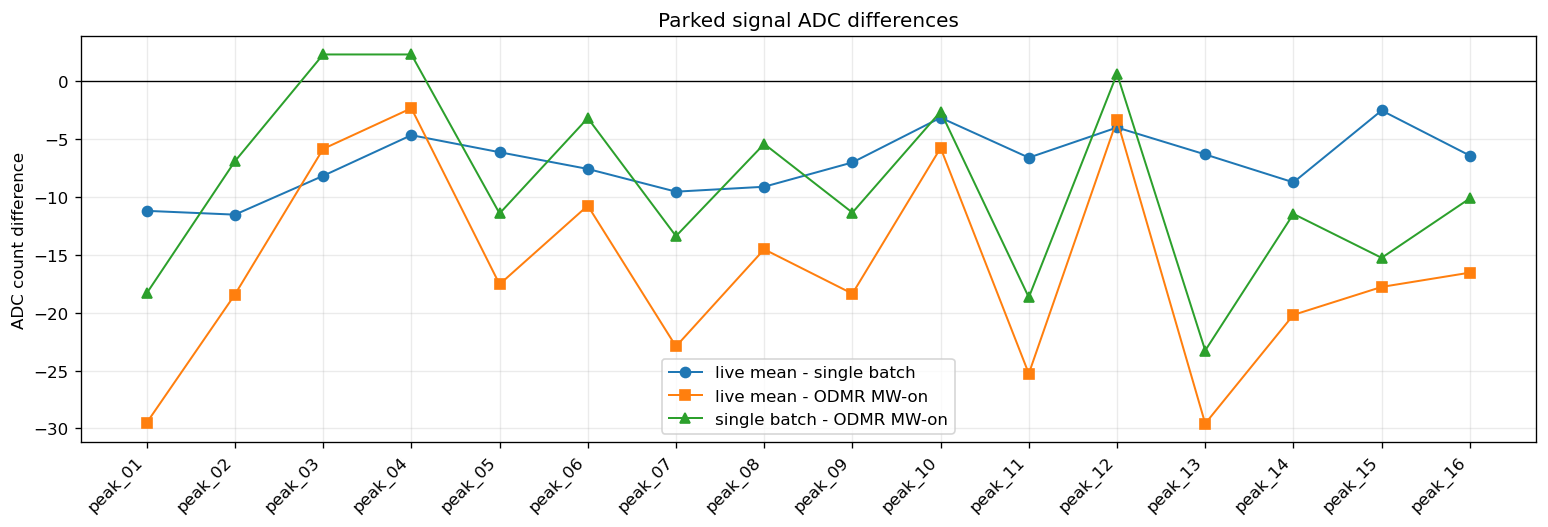

In [6]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axhline(0, color="black", lw=0.8)
ax.plot(x, comparison["live_minus_batch_adc"], marker="o", lw=1.2, label="live mean - single batch")
ax.plot(x, comparison["live_minus_odmr_adc"], marker="s", lw=1.2, label="live mean - ODMR MW-on")
ax.plot(x, comparison["batch_minus_odmr_adc"], marker="^", lw=1.2, label="single batch - ODMR MW-on")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("ADC count difference")
ax.set_title("Parked signal ADC differences")
ax.legend()
fig.tight_layout()
plot_path = OUT_DIR / f"signal_adc_differences_{RUN_LABEL}.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
print(f"Saved: {plot_path}")
render(fig)

## Normalized signal/reference comparison

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/signal_over_reference_20260508_151729.png


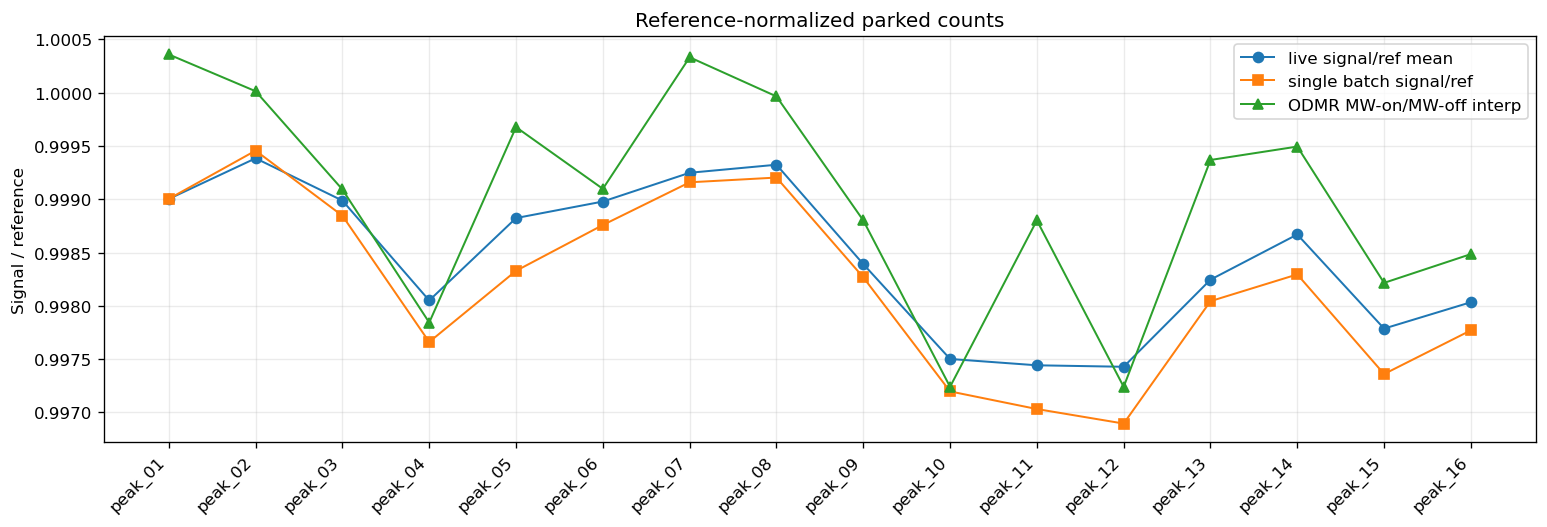

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(x, comparison["live_signal_over_ref_mean"], marker="o", lw=1.2, label="live signal/ref mean")
ax.plot(x, comparison["batch_signal_over_ref"], marker="s", lw=1.2, label="single batch signal/ref")
ax.plot(x, comparison["odmr_signal_over_ref_interp"], marker="^", lw=1.2, label="ODMR MW-on/MW-off interp")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Signal / reference")
ax.set_title("Reference-normalized parked counts")
ax.legend()
fig.tight_layout()
plot_path = OUT_DIR / f"signal_over_reference_{RUN_LABEL}.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
print(f"Saved: {plot_path}")
render(fig)

## Live time traces with batch and ODMR reference levels

Use `PEAKS_TO_PLOT` to select specific parked points.

Saved: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/adc_count_comparisons/live_signal_time_traces_selected_20260508_151729.png


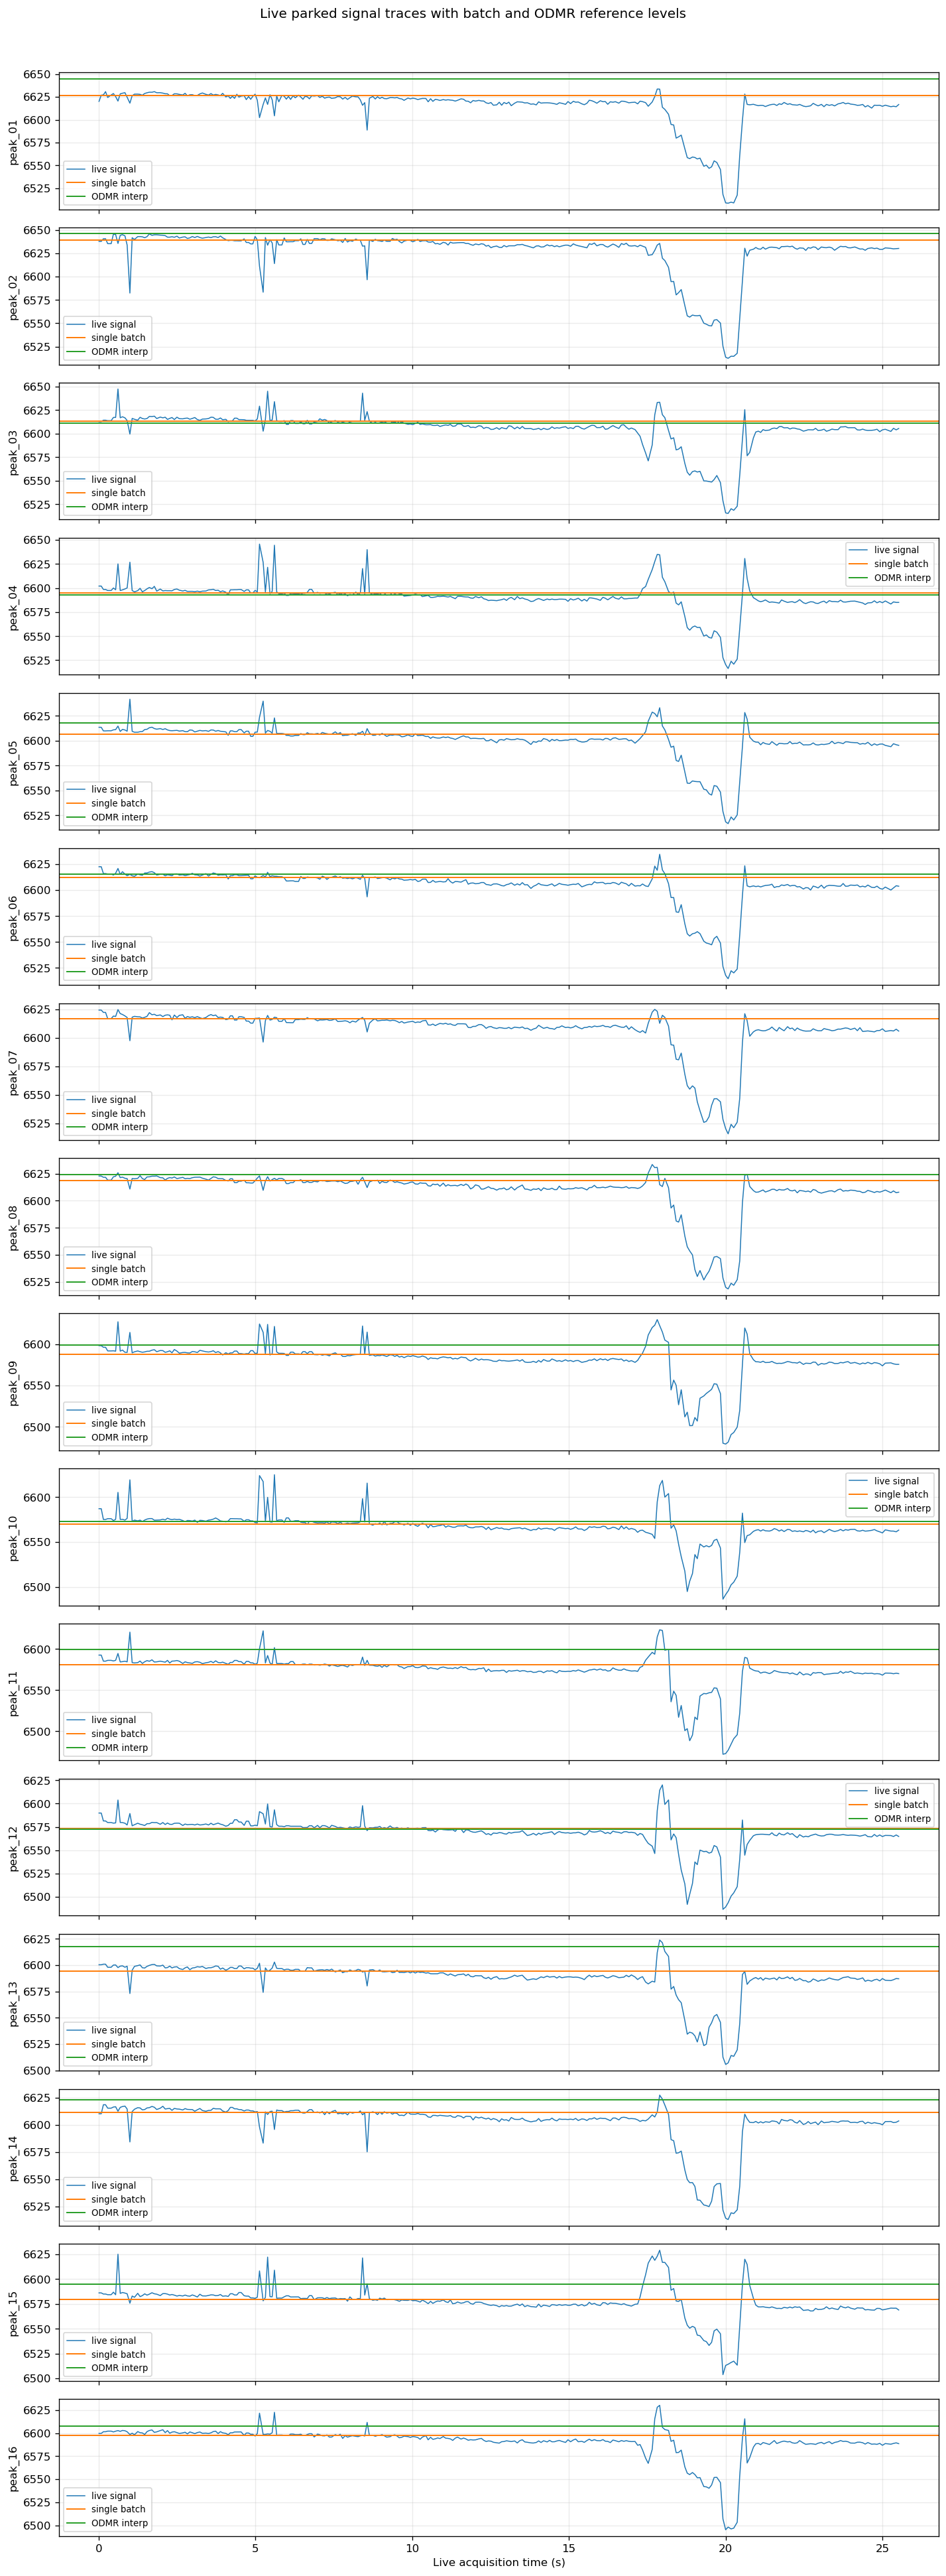

In [8]:
PEAKS_TO_PLOT = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
available = [n for n in PEAKS_TO_PLOT if n in peak_nums]
fig, axes = plt.subplots(len(available), 1, figsize=(12, max(2.0 * len(available), 4)), sharex=True)
if len(available) == 1:
    axes = [axes]

time_s = live_df["time_s"].to_numpy(dtype=float) if "time_s" in live_df.columns else np.arange(len(live_df), dtype=float)
for ax, n in zip(axes, available):
    peak = f"peak_{n:02d}"
    row = comparison.loc[comparison["peak"] == peak].iloc[0]
    ax.plot(time_s, live_df[peak].to_numpy(dtype=float), lw=0.9, label="live signal")
    ax.axhline(row["batch_signal_adc"], color="tab:orange", lw=1.2, label="single batch")
    ax.axhline(row["odmr_signal_interp_adc"], color="tab:green", lw=1.2, label="ODMR interp")
    ax.set_ylabel(peak)
    ax.legend(loc="best", fontsize=8)
axes[-1].set_xlabel("Live acquisition time (s)")
fig.suptitle("Live parked signal traces with batch and ODMR reference levels", y=1.01)
fig.tight_layout()
plot_path = OUT_DIR / f"live_signal_time_traces_selected_{RUN_LABEL}.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
print(f"Saved: {plot_path}")
render(fig)

## Quick takeaways

In [9]:
mean_live_minus_batch = comparison["live_minus_batch_adc"].mean()
mean_live_minus_odmr = comparison["live_minus_odmr_adc"].mean()
max_abs_plan_mismatch = np.nanmax(np.abs(freq_check["live_minus_plan_mhz"].to_numpy(dtype=float)))

print(f"Mean live signal - single batch: {mean_live_minus_batch:.3f} ADC")
print(f"Mean live signal - ODMR MW-on interp: {mean_live_minus_odmr:.3f} ADC")
print(f"Max |live parked freq - plan freq|: {max_abs_plan_mismatch:.3f} MHz")

largest = comparison.reindex(comparison["live_minus_odmr_adc"].abs().sort_values(ascending=False).index).head(5)
print("\nLargest live-vs-ODMR signal differences:")
display(largest[["peak", "freq_mhz", "live_minus_odmr_adc", "live_minus_batch_adc", "odmr_signal_interp_adc"]].round(3))

Mean live signal - single batch: -7.035 ADC
Mean live signal - ODMR MW-on interp: -16.161 ADC
Max |live parked freq - plan freq|: 140.688 MHz

Largest live-vs-ODMR signal differences:


,peak,freq_mhz,live_minus_odmr_adc,live_minus_batch_adc,odmr_signal_interp_adc
12,peak_13,2941.0,-29.580,-6.316,6617.411
0,peak_01,2629.0,-29.507,-11.191,6644.757
10,peak_11,2878.0,-25.265,-6.595,6599.307
6,peak_07,2838.0,-22.911,-9.534,6630.115
13,peak_14,2947.0,-20.185,-8.728,6622.863
